In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import get_scorer
from tqdm import tqdm   # <- progress bar
import os
from sklearn.inspection import permutation_importance


In [2]:
#pip install tqdm

In [3]:
def train_perm_importance_gb(
    df, target,
    test_size=0.3,
    random_state=42,
    scoring="roc_auc",
    n_repeats=10
):
    """
    Fast, self-contained permutation-importance workflow using a light GradientBoostingClassifier.
    - Uses ONLY numeric features (keeps it quick; avoids encoding).
    - Median-imputes missing numerics.
    - Trains a small GB model.
    - Computes permutation importance on the held-out test set.

    Returns:
        df_imp  : DataFrame [rank, feature, importance_mean, importance_std]
        result  : sklearn permutation_importance result (for advanced plotting)
        pipe    : fitted sklearn Pipeline (imputer + model)
        X_test  : test features (DataFrame, post column selection)
        y_test  : test targets (Series)
    """
    # Split features / target
    y = df[target]
    X = df.drop(columns=[target])

    # Keep only numeric columns for speed & simplicity
    num_cols = X.select_dtypes(include=[np.number]).columns
    X = X[num_cols].copy()

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y if y.nunique() == 2 else None
    )

    # Lightweight Gradient Boosting model
    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(
            n_estimators=120,        # small, quick
            learning_rate=0.08,
            max_depth=3,
            subsample=0.9,
            random_state=random_state
        ))
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Permutation importance on held-out test set
    result = permutation_importance(
        pipe, X_test, y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=None
    )

    # Rank table
    df_imp = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    df_imp["rank"] = np.arange(1, len(df_imp) + 1)
    df_imp = df_imp[["rank", "feature", "importance_mean", "importance_std"]]

    return df_imp, result

# def train_perm_importance_gb(
#     df, target,
#     test_size=0.3,
#     random_state=42,
#     scoring="roc_auc",
#     n_repeats=10
# ):
    

# """
#     Fast, self-contained permutation-importance workflow using a light GradientBoostingClassifier.
#     - Uses ONLY numeric features (keeps it quick; avoids encoding).
#     - Median-imputes missing numerics.
#     - Trains a small GB model.
#     - Computes permutation importance on the held-out test set.
#     Returns:
#         df_imp  : DataFrame [rank, feature, importance_mean, importance_std]
#         result  : sklearn permutation_importance result (for advanced plotting)
#         pipe    : fitted sklearn Pipeline (imputer + model)
#         X_test  : test features (DataFrame, post column selection)
#         y_test  : test targets (Series)
# """

#     y = df[target]
#     X = df.drop(columns=[target])

#     # Keep only numeric columns
#     num_cols = X.select_dtypes(include=[np.number]).columns
#     X = X[num_cols].copy()

#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=test_size, random_state=random_state,
#         stratify=y if y.nunique() == 2 else None
#     )

#     pipe = Pipeline(steps=[
#         ("imputer", SimpleImputer(strategy="median")),
#         ("model", GradientBoostingClassifier(
#             n_estimators=120,
#             learning_rate=0.08,
#             max_depth=3,
#             subsample=0.9,
#             random_state=random_state
#         ))
#     ])

#     pipe.fit(X_train, y_train)

#     # Custom permutation importance with progress bar
#     scorer = get_scorer(scoring)
#     baseline = scorer(pipe, X_test, y_test)

#     rng = np.random.RandomState(random_state)
#     importances = np.zeros((X_test.shape[1], n_repeats))

#     for n in tqdm(range(n_repeats), desc="Permutation Progress"):
#         for col_idx, col in enumerate(X_test.columns):
#             X_permuted = X_test.copy()
#             X_permuted[col] = rng.permutation(X_permuted[col].values)
#             score = scorer(pipe, X_permuted, y_test)
#             importances[col_idx, n] = baseline - score

#     means = importances.mean(axis=1)
#     stds = importances.std(axis=1)

#     df_imp = pd.DataFrame({
#         "feature": X_test.columns,
#         "importance_mean": means,
#         "importance_std": stds
#     }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

#     df_imp["rank"] = np.arange(1, len(df_imp) + 1)
#     df_imp = df_imp[["rank", "feature", "importance_mean", "importance_std"]]

#     return df_imp, importances, pipe, X_test, y_test




def plot_perm_importance_bar(df_imp, top_n=20, title="Permutation Importance (top features)"):
    """
    Horizontal bar chart of permutation importance with error bars (±1 std).
    """
    d = df_imp.head(top_n).iloc[::-1]  # reverse so most important at top
    plt.figure(figsize=(10, 6))
    plt.barh(d["feature"], d["importance_mean"], xerr=d["importance_std"], align="center")
    plt.xlabel("Decrease in score (mean ± std)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# def plot_perm_importance_box(result, feature_names, top_n=20, title="Permutation Importance (boxplot)"):
#     """
#     Boxplot style similar to the sklearn example:
#     https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html
#     """
#     means = result.importances_mean
#     idx_sorted = np.argsort(means)[::-1][:top_n]
#     data = result.importances[idx_sorted].T  # shape: (n_repeats, n_features_selected)
#     labels = np.array(feature_names)[idx_sorted]

#     plt.figure(figsize=(10, 6))
#     plt.boxplot(data, vert=False, labels=labels)
#     plt.axvline(0, linestyle="--", color="gray", linewidth=1)
#     plt.xlabel("Decrease in score when permuted")
#     plt.title(title)
#     plt.tight_layout()
#     plt.show()


def plot_perm_importance_box(importances_or_result, feature_names, top_n=20,
                             title="Permutation Importance (boxplot)"):
    """
    Accepts either:
      - sklearn PermutationImportanceResult (has .importances and .importances_mean), or
      - raw ndarray (n_features, n_repeats) as returned by the custom progress loop.
    """
    # Detect type
    if hasattr(importances_or_result, "importances_mean"):  # sklearn object
        importances = importances_or_result.importances      # (n_features, n_repeats)
        means = importances_or_result.importances_mean       # (n_features,)
    else:  # numpy array from our custom function
        importances = np.asarray(importances_or_result)      # (n_features, n_repeats)
        means = importances.mean(axis=1)

    # get top_n indices
    idx_sorted = np.argsort(means)[::-1][:top_n]
    data = importances[idx_sorted].T          # (n_repeats, top_n)
    labels = np.array(feature_names)[idx_sorted]

    # plot
    plt.figure(figsize=(10, 6))
    plt.boxplot(data, vert=False, labels=labels)
    plt.axvline(0, linestyle="--", color="gray", linewidth=1)
    plt.xlabel("Decrease in score when permuted")
    plt.title(title)
    plt.tight_layout()
    plt.show()



def save_file(df, output_file = "Modulo1633_REC41_2024_fil_clear.csv"):

    # File name only

    # Go one level up from the current working directory
    base_dir = os.path.dirname(os.getcwd())   # gives "c:\\Users\\linoc\\OneDrive\\Encoder\\03_partos"
    output_dir = os.path.join(base_dir, "03_bases_intermediarios")

    #Full path
    output_path = os.path.join(output_dir, output_file)

    # Save DataFrame
    df.to_csv(output_path, index=False, encoding="utf-8-sig")


## Modulo1633_REC41_2024_fil_clear

In [5]:
# Build base directory (go up one level from current /02_scripts)
base_dir = os.path.dirname(os.getcwd())   # → c:\Users\linoc\OneDrive\Encoder\03_partos

csv_path_target_final = os.path.join(base_dir,"03_bases_intermediarios", "target_final.csv")
csv_path_Modulo1632_RE223132_2024_clear = os.path.join(base_dir,"03_bases_intermediarios", "Modulo1633_REC41_2024_fil_clear.csv")


# Load the dataset
target_final = pd.read_csv(csv_path_target_final,usecols = ['CASEID','premature_flag'], low_memory=False)
Modulo1633_REC41_2024_fil_clear = pd.read_csv(csv_path_Modulo1632_RE223132_2024_clear, low_memory=False)

target_final.shape, Modulo1633_REC41_2024_fil_clear.shape

((18335, 2), (17608, 467))

In [5]:
Modulo1633_REC41_2024_fil_clear = Modulo1633_REC41_2024_fil_clear.merge(target_final, how= 'left', on ='CASEID')
Modulo1633_REC41_2024_fil_clear = Modulo1633_REC41_2024_fil_clear.dropna()
Modulo1633_REC41_2024_fil_clear.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 5581 entries, 5 to 17607
Data columns (total 468 columns):
 #    Column          Non-Null Count  Dtype  
---   ------          --------------  -----  
 0    CASEID          5581 non-null   object 
 1    M2A             5581 non-null   int64  
 2    M2B             5581 non-null   int64  
 3    M2C             5581 non-null   int64  
 4    M2D             5581 non-null   int64  
 5    M2E             5581 non-null   int64  
 6    M2G             5581 non-null   int64  
 7    M2K             5581 non-null   int64  
 8    M2N             5581 non-null   int64  
 9    M3A             5581 non-null   int64  
 10   M3B             5581 non-null   int64  
 11   M3C             5581 non-null   int64  
 12   M3D             5581 non-null   int64  
 13   M3E             5581 non-null   int64  
 14   M3G             5581 non-null   int64  
 15   M3H             5581 non-null   int64  
 16   M3K             5581 non-null   int64  
 17   M3N             

In [6]:
df_imp, result = train_perm_importance_gb(
    Modulo1633_REC41_2024_fil_clear, target="premature_flag", scoring="roc_auc", n_repeats=15
)

In [7]:
save_file(df_imp, output_file = "RANK_Modulo1633_REC41_2024_fil_clear.csv")

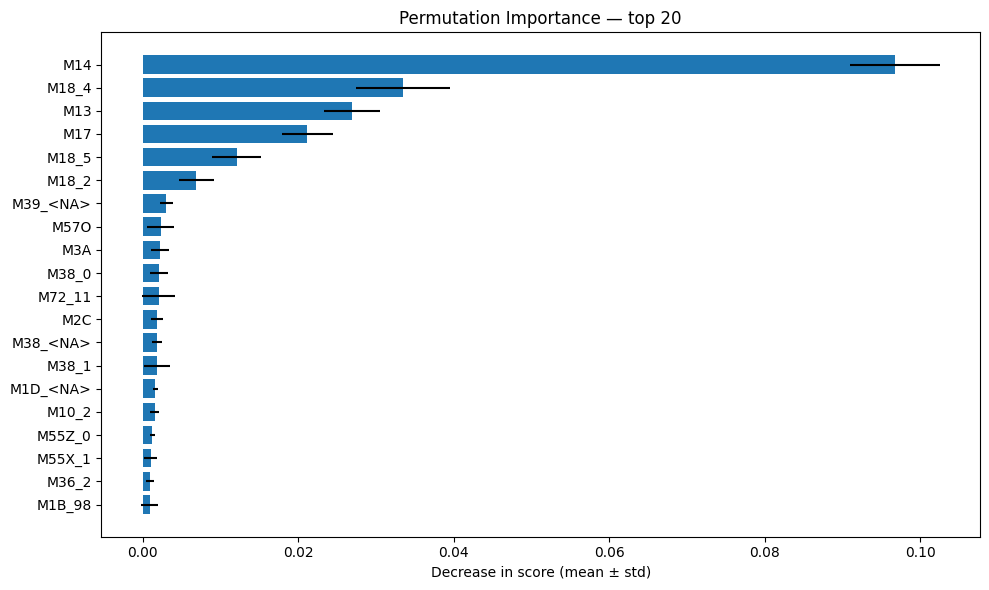

In [8]:
# Plot top 20 as bars
plot_perm_importance_bar(df_imp, top_n=20, title="Permutation Importance — top 20")

In [9]:
# # Or boxplot style (uses the raw importance samples)
# plot_perm_importance_box(result, feature_names=X_test.columns, top_n=20,
#                          title="Permutation Importance (boxplot) — top 20")

## Modulo1633_REC94_2024_fil_clear

In [3]:
csv_path_Modulo1633_REC94_2024_fil_clear = os.path.join(base_dir,"03_bases_intermediarios", "Modulo1633_REC94_2024_fil_clear.csv")
Modulo1633_REC94_2024_fil_clear = pd.read_csv(csv_path_Modulo1633_REC94_2024_fil_clear, low_memory=False)

Modulo1633_REC94_2024_fil_clear = Modulo1633_REC94_2024_fil_clear.merge(target_final, how= 'left', on ='CASEID')
Modulo1633_REC94_2024_fil_clear = Modulo1633_REC94_2024_fil_clear.dropna()
Modulo1633_REC94_2024_fil_clear.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 17607 entries, 0 to 17607
Data columns (total 270 columns):
 #    Column          Non-Null Count  Dtype  
---   ------          --------------  -----  
 0    S426E           17607 non-null  float64
 1    S430D           17607 non-null  float64
 2    S436C           17607 non-null  float64
 3    S441            17607 non-null  float64
 4    ID1_2024        17607 non-null  float64
 5    S410B_<NA>      17607 non-null  float64
 6    S411B_<NA>      17607 non-null  float64
 7    S411F_<NA>      17607 non-null  float64
 8    S411G_<NA>      17607 non-null  float64
 9    S411H_<NA>      17607 non-null  float64
 10   S411I_<NA>      17607 non-null  float64
 11   S411J_<NA>      17607 non-null  float64
 12   S411K_<NA>      17607 non-null  float64
 13   S411L_<NA>      17607 non-null  float64
 14   S411BA_<NA>     17607 non-null  float64
 15   S411CA_<NA>     17607 non-null  float64
 16   S411DA_<NA>     17607 non-null  float64
 17   S411EA_<NA>    

In [7]:
RANK_Modulo1633_REC94_2024_fil_clear, result_Modulo1633_REC94_2024_fil_clear, = train_perm_importance_gb(
    Modulo1633_REC94_2024_fil_clear, target="premature_flag", scoring="roc_auc", n_repeats=15
)

In [10]:
save_file(RANK_Modulo1633_REC94_2024_fil_clear, output_file = "RANK_Modulo1633_REC94_2024_fil_clear.csv")

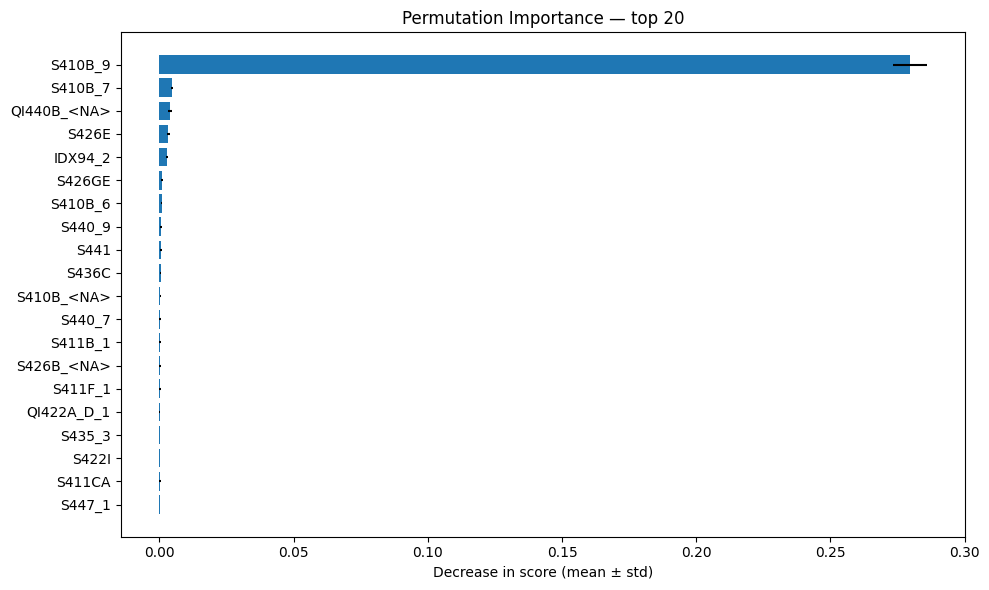

In [11]:
plot_perm_importance_bar(RANK_Modulo1633_REC94_2024_fil_clear, top_n=20, title="Permutation Importance — top 20")

In [13]:
# # Or boxplot style (uses the raw importance samples)
# plot_perm_importance_box(result_Modulo1633_REC94_2024_fil_clear, feature_names=X_test.columns, top_n=20,
#                          title="Permutation Importance (boxplot) — top 20")

## Modulo1631_REC91_2024_M_clear

In [10]:
csv_path_Modulo1631_REC91_2024_M_clear = os.path.join(base_dir,"03_bases_intermediarios", "Modulo1631_REC91_2024_M_clear.csv")
Modulo1631_REC91_2024_M_clear = pd.read_csv(csv_path_Modulo1631_REC91_2024_M_clear, low_memory=False)

Modulo1631_REC91_2024_M_clear.shape, Modulo1631_REC91_2024_M_clear.CASEID.nunique()

((37117, 132), 37117)

In [11]:
Modulo1631_REC91_2024_M_clear = Modulo1631_REC91_2024_M_clear.merge(target_final, how= 'left', on ='CASEID')
Modulo1631_REC91_2024_M_clear = Modulo1631_REC91_2024_M_clear.dropna()
Modulo1631_REC91_2024_M_clear.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 18334 entries, 0 to 37115
Data columns (total 133 columns):
 #    Column          Non-Null Count  Dtype  
---   ------          --------------  -----  
 0    ID1             18334 non-null  float64
 1    SREGION         18334 non-null  float64
 2    SSEMES          18334 non-null  float64
 3    SPROVIN         18334 non-null  float64
 4    SDISTRI         18334 non-null  float64
 5    S108N           18334 non-null  float64
 6    S108Y           18334 non-null  float64
 7    S119            18334 non-null  float64
 8    S119NA          18334 non-null  float64
 9    S119NB          18334 non-null  float64
 10   S119D           18334 non-null  float64
 11   S489C           18334 non-null  float64
 12   S489D           18334 non-null  float64
 13   S490            18334 non-null  float64
 14   S704N           18334 non-null  float64
 15   S704Y           18334 non-null  float64
 16   S802            18334 non-null  float64
 17   S802D          

In [12]:
RANK_Modulo1631_REC91_2024_M_clear,result_Modulo1631_REC91_2024_M_clear, = train_perm_importance_gb(
    Modulo1631_REC91_2024_M_clear, target="premature_flag", scoring="roc_auc", n_repeats=15
)

In [13]:
RANK_Modulo1631_REC91_2024_M_clear

,rank,feature,importance_mean,importance_std
0,1,SREGION,0.044081,0.007891
1,2,SDISTRI,0.006837,0.002036
2,3,S490AB,0.005018,0.002404
3,4,S802,0.004463,0.002529
4,5,S119,0.003713,0.001719
...,...,...,...,...
126,127,S1002A,-0.000563,0.000313
127,128,S807,-0.000590,0.000459
128,129,S490AE,-0.000623,0.000374
129,130,S803AF,-0.000654,0.000326


In [14]:
save_file(RANK_Modulo1631_REC91_2024_M_clear, output_file = "RANK_Modulo1631_REC91_2024_M_clear.csv")

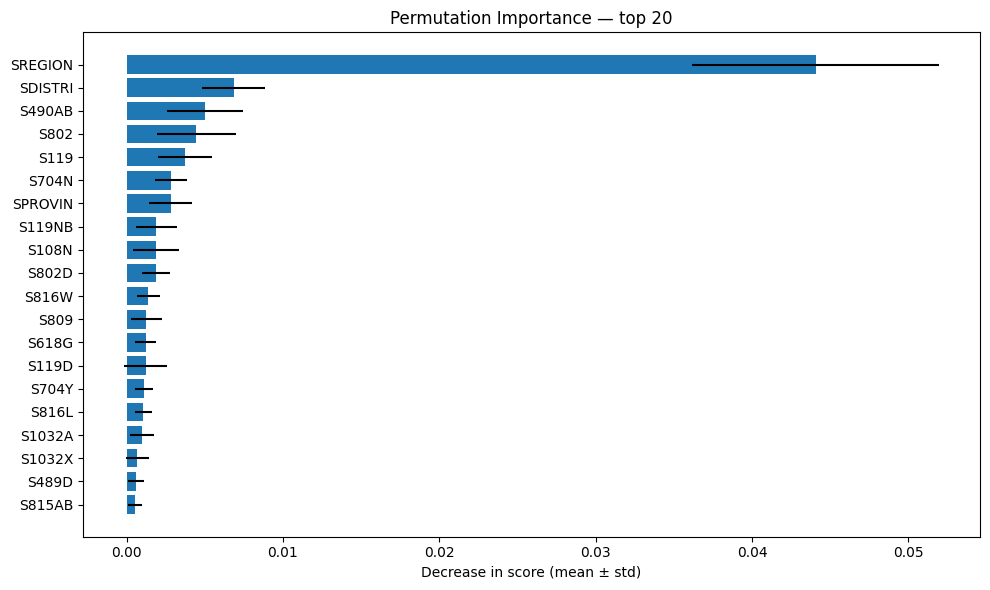

In [15]:
plot_perm_importance_bar(RANK_Modulo1631_REC91_2024_M_clear, top_n=20, title="Permutation Importance — top 20")

## Modulo1632_RE223132_2024

In [6]:
csv_path_Modulo1632_RE223132_2024_M_clear = os.path.join(base_dir,"03_bases_intermediarios", "Modulo1632_RE223132_2024_M_clear.csv")
Modulo1632_RE223132_2024_M_clear = pd.read_csv(csv_path_Modulo1632_RE223132_2024_M_clear, low_memory=False)
Modulo1632_RE223132_2024_M_clear.shape, Modulo1632_RE223132_2024_M_clear.CASEID.nunique()

((34252, 65), 34252)

In [7]:
Modulo1632_RE223132_2024_M_clear = Modulo1632_RE223132_2024_M_clear.merge(target_final, how= 'left', on ='CASEID')
Modulo1632_RE223132_2024_M_clear = Modulo1632_RE223132_2024_M_clear.dropna()
Modulo1632_RE223132_2024_M_clear.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 18334 entries, 0 to 34250
Data columns (total 66 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID1             18334 non-null  float64
 1   V201            18334 non-null  float64
 2   V202            18334 non-null  float64
 3   V203            18334 non-null  float64
 4   V204            18334 non-null  float64
 5   V205            18334 non-null  float64
 6   V206            18334 non-null  float64
 7   V207            18334 non-null  float64
 8   V208            18334 non-null  float64
 9   V209            18334 non-null  float64
 10  V210            18334 non-null  float64
 11  V211            18334 non-null  float64
 12  V212            18334 non-null  float64
 13  V215            18334 non-null  float64
 14  V217            18334 non-null  float64
 15  V218            18334 non-null  float64
 16  V219            18334 non-null  float64
 17  V220            18334 non-null  floa

In [8]:
RANK_Modulo1632_RE223132_2024_M_clear,result_Modulo1632_RE223132_2024_M_clear, = train_perm_importance_gb(
    Modulo1632_RE223132_2024_M_clear, target="premature_flag", scoring="roc_auc", n_repeats=15
)

In [9]:
RANK_Modulo1632_RE223132_2024_M_clear

,rank,feature,importance_mean,importance_std
0,1,V305_06,0.039720,0.006991
1,2,V208,0.014651,0.004809
2,3,V218,0.012758,0.002466
3,4,V228,0.012574,0.002272
4,5,V212,0.010310,0.003407
...,...,...,...,...
59,60,V305_09,-0.001039,0.000540
60,61,V312,-0.001133,0.000779
61,62,V305_08,-0.001190,0.000509
62,63,V215,-0.001206,0.001038


In [10]:
save_file(RANK_Modulo1632_RE223132_2024_M_clear, output_file = "RANK_Modulo1632_RE223132_2024_M_clear.csv")

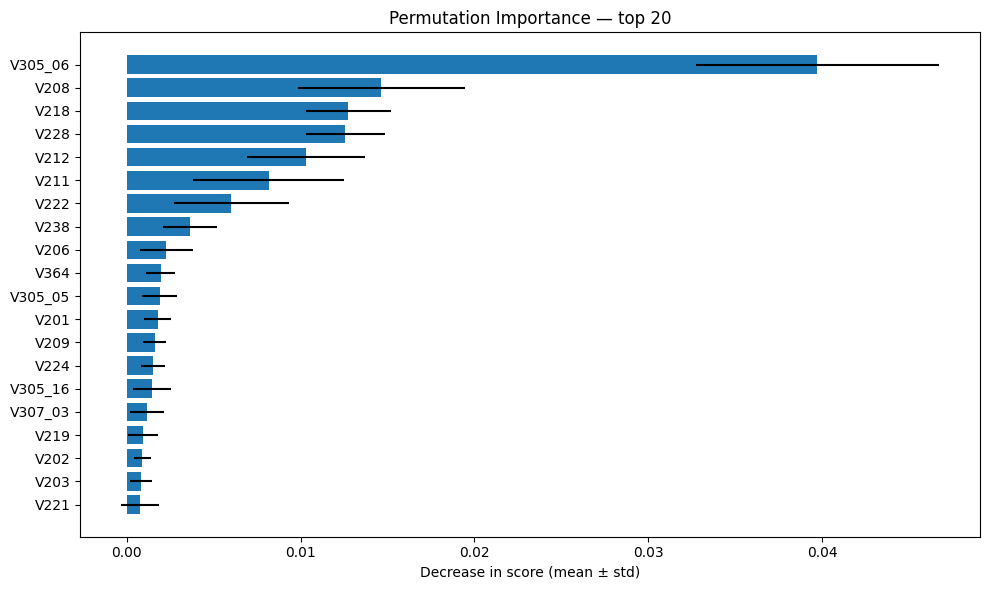

In [11]:
plot_perm_importance_bar(RANK_Modulo1632_RE223132_2024_M_clear, top_n=20, title="Permutation Importance — top 20")

## Modulo1635_RE516171_2024

In [22]:
csv_path_Modulo1635_RE516171_2024_M_clear = os.path.join(base_dir,"03_bases_intermediarios", "Modulo1635_RE516171_2024_M_clear.csv")
Modulo1635_RE516171_2024_M_clear = pd.read_csv(csv_path_Modulo1635_RE516171_2024_M_clear, low_memory=False)
Modulo1635_RE516171_2024_M_clear.shape, Modulo1635_RE516171_2024_M_clear.CASEID.nunique()

((34252, 63), 34252)

In [23]:
Modulo1635_RE516171_2024_M_clear = Modulo1635_RE516171_2024_M_clear.merge(target_final, how= 'left', on ='CASEID')
Modulo1635_RE516171_2024_M_clear = Modulo1635_RE516171_2024_M_clear.dropna()
Modulo1635_RE516171_2024_M_clear.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 18334 entries, 0 to 34250
Data columns (total 64 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID1             18334 non-null  float64
 1   V501            18334 non-null  float64
 2   V502            18334 non-null  float64
 3   V503            18334 non-null  float64
 4   V504            18334 non-null  float64
 5   V507            18334 non-null  float64
 6   V508            18334 non-null  float64
 7   V509            18334 non-null  float64
 8   V510            18334 non-null  float64
 9   V511            18334 non-null  float64
 10  V512            18334 non-null  float64
 11  V513            18334 non-null  float64
 12  V525            18334 non-null  float64
 13  V527            18334 non-null  float64
 14  V528            18334 non-null  float64
 15  V529            18334 non-null  float64
 16  V530            18334 non-null  float64
 17  V531            18334 non-null  floa

In [24]:
RANK_MModulo1635_RE516171_2024_M_clear,result_Modulo1635_RE516171_2024_M_clear, = train_perm_importance_gb(
    Modulo1635_RE516171_2024_M_clear, target="premature_flag", scoring="roc_auc", n_repeats=15
)

In [25]:
save_file(RANK_MModulo1635_RE516171_2024_M_clear, output_file = "RANK_MModulo1635_RE516171_2024_M_clear.csv")

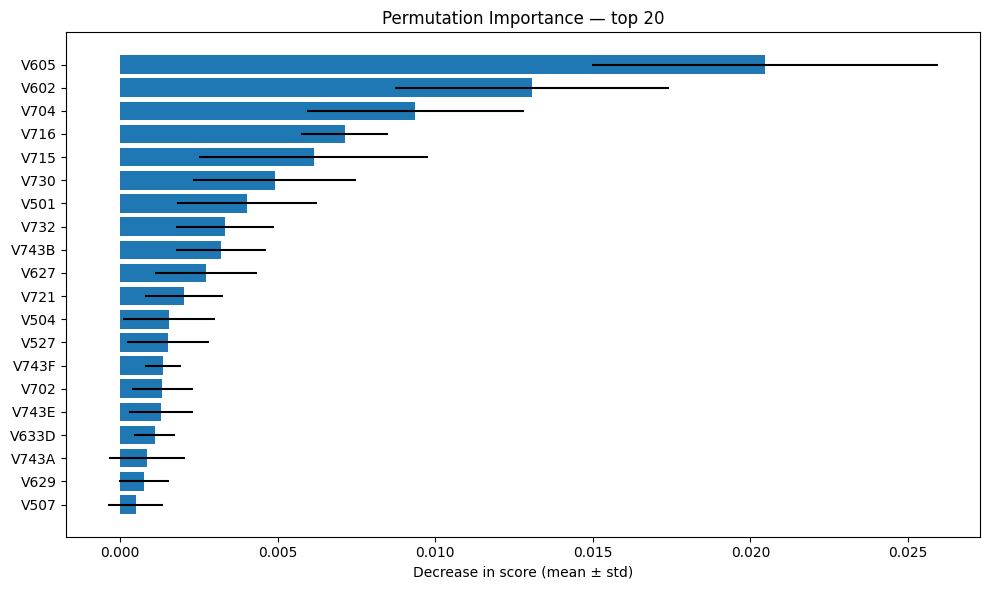

In [26]:
plot_perm_importance_bar(RANK_MModulo1635_RE516171_2024_M_clear, top_n=20, title="Permutation Importance — top 20")